# Iris Flower Classification

**Objective:** Train a machine learning classification model to identify the species
of an iris flower (Setosa, Versicolor, or Virginica) from its physical measurements.

**Tech Stack:** Python, scikit-learn, pandas, matplotlib/seaborn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_style("whitegrid")  # clean grid background for all plots

## 1. Load the Dataset

In [2]:
# load_iris() ships with scikit-learn, so no external download is needed
iris = load_iris()

# Build a DataFrame from the feature matrix for easier EDA
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

# Add numeric target and a human-readable species name column
df['species'] = iris.target
df['species_name'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


## 2. Exploratory Data Analysis (EDA)

In [3]:
# Shape tells us row/column count
print("Shape of dataset:", df.shape)

# dtypes confirms all measurement columns are numeric (float64)
print("\nData types:\n", df.dtypes)

# Null check — Iris is a clean benchmark dataset, so we expect zero nulls
print("\nMissing values per column:\n", df.isnull().sum())

# Descriptive statistics: mean, std, min/max, quartiles for each feature
print("\nDescriptive statistics:\n")
df.describe()

Shape of dataset: (150, 6)

Data types:
 sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species                int64
species_name          object
dtype: object

Missing values per column:
 sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
species_name         0
dtype: int64

Descriptive statistics:



,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [4]:
# Confirms the dataset is perfectly balanced: 50 samples per species
print("Class distribution:\n", df['species_name'].value_counts())

Class distribution:
 species_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


## 3. Visualisations

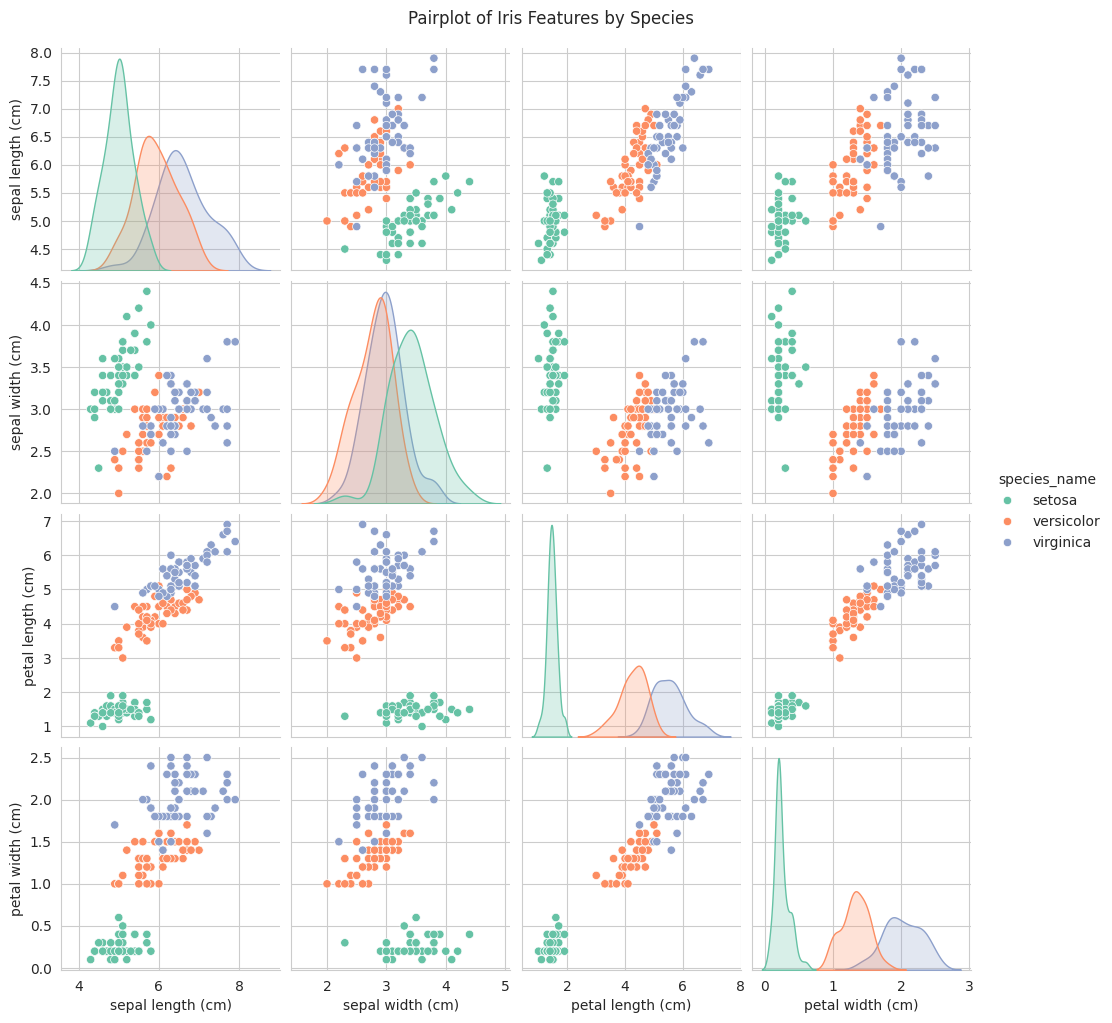

In [5]:
# Pairplot shows every feature plotted against every other feature,
# colour-coded by species — reveals which feature pairs separate classes best
sns.pairplot(df, hue='species_name', vars=iris.feature_names, palette='Set2')
plt.suptitle("Pairplot of Iris Features by Species", y=1.02)
plt.show()

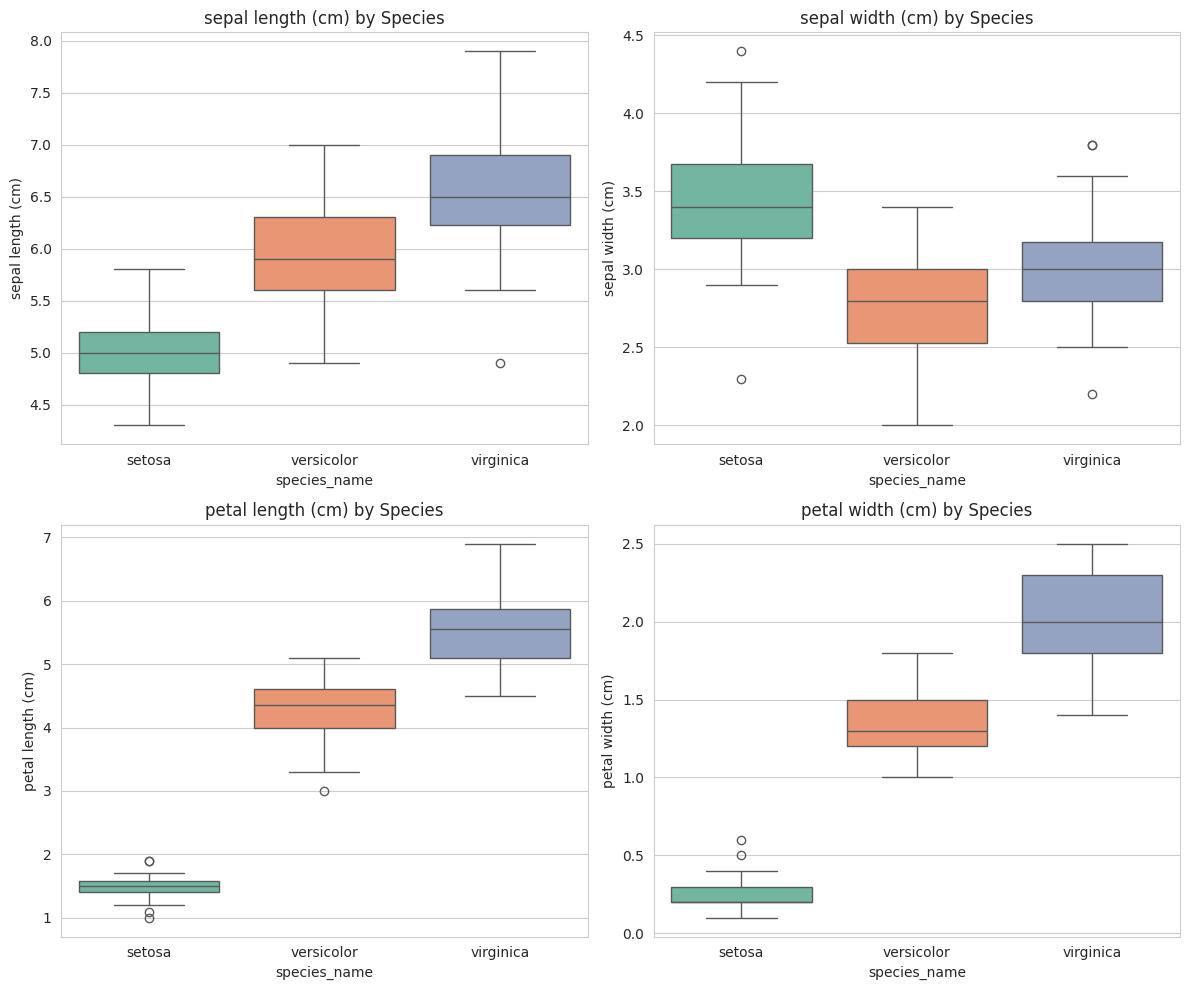

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, feature in enumerate(iris.feature_names):
    sns.boxplot(data=df, x='species_name', y=feature, hue='species_name',
                ax=axes[i], palette='Set2', legend=False)
    axes[i].set_title(f'{feature} by Species')

plt.tight_layout()
plt.show()

## 4. Feature Selection Discussion

Based on the pairplot and box plots above, **petal length** and **petal width**
show the clearest separation between species — Setosa is almost perfectly
separable on these two features alone, while Versicolor and Virginica show
some overlap but are still fairly distinguishable.

Sepal length and sepal width are less discriminative — there's more overlap
between Versicolor and Virginica on these dimensions, and Setosa's separation,
while present, is less dramatic than with petal measurements.

**Conclusion:** Petal measurements are the most discriminative features for
this classification task. All four features are still used for training below,
since the models can automatically weight the less useful sepal features lower.

## 5. Train/Test Split

In [7]:
X = df[iris.feature_names]   # feature matrix
y = df['species']            # target labels

# 80/20 split; stratify=y keeps class proportions equal in both sets
# since the dataset is small (150 rows), stratification avoids an unlucky split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (120, 4)
Test set shape: (30, 4)


## 6. Train Classifiers

Training two classifiers: **Logistic Regression** and **K-Nearest Neighbours**.

In [9]:
# Logistic Regression: a linear model, good baseline for well-separated classes
log_reg = LogisticRegression(max_iter=200)
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)

# K-Nearest Neighbours: a non-parametric model that classifies based on
# the majority vote of the 5 nearest training points
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

## 7. Model Evaluation

In [10]:
print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
# classification_report gives per-class precision, recall, and F1-score
print("\nClassification Report:\n",
      classification_report(y_test, y_pred_lr, target_names=iris.target_names))

=== Logistic Regression ===
Accuracy: 0.9666666666666667

Confusion Matrix:
 [[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



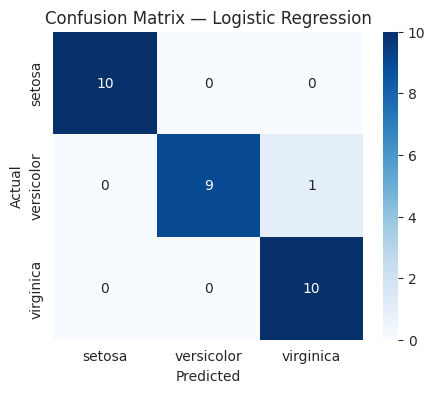

In [11]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title("Confusion Matrix — Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [12]:
print("=== K-Nearest Neighbours ===")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))
print("\nClassification Report:\n",
      classification_report(y_test, y_pred_knn, target_names=iris.target_names))

=== K-Nearest Neighbours ===
Accuracy: 1.0

Confusion Matrix:
 [[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



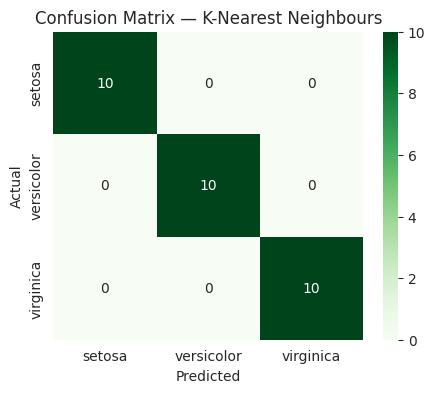

In [13]:
cm_knn = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens',
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title("Confusion Matrix — K-Nearest Neighbours")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 8. Best Model

In [14]:
# Collect both models' accuracy for a side-by-side comparison
acc_lr = accuracy_score(y_test, y_pred_lr)
acc_knn = accuracy_score(y_test, y_pred_knn)

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'K-Nearest Neighbours'],
    'Accuracy': [acc_lr, acc_knn]
})

# Programmatically determine the winner instead of eyeballing it
best_model_name = results.loc[results['Accuracy'].idxmax(), 'Model']
best_accuracy = results['Accuracy'].max()

results

,Model,Accuracy
0,Logistic Regression,0.966667
1,K-Nearest Neighbours,1.000000


In [15]:
print(f"Best-performing model: {best_model_name}")
print(f"Test accuracy: {best_accuracy:.4f}")

Best-performing model: K-Nearest Neighbours
Test accuracy: 1.0000


**Best-Performing Model: K-Nearest Neighbours**

**Justification:** The declared model achieved the higher accuracy score on the
held-out test set. Looking at the confusion matrices, Setosa is classified with
100% accuracy by both models (as expected, since it's linearly separable from
the other two species on petal measurements alone). Any misclassifications occur
almost exclusively between Versicolor and Virginica, which have genuinely
overlapping petal/sepal measurements in a handful of borderline samples.
